In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  
# os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  
from torch import nn


import numpy as np                                                                  
import torch                                          

                              
from transformers import AutoModelForCausalLM, AutoTokenizer  
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt  
import torch.nn.functional as F
import gc
import re
import copy

import JCBScope_utils

# Move to GPU with optimal dtype
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = "cpu"


/home/jl3499/conda/LLM1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jl3499/conda/LLM1/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
mode = 'Temperature'
# mode = 'Semantic'
if mode not in ["Temperature", "Semantic"]:
    raise ValueError(f"Invalid mode '{mode}'. Mode must be either 'Temperature' or 'Semantic'.")

In [16]:
# Load the tokenizer and model

# model_name = "meta-llama/Llama-3.2-1B"
# model_name = "meta-llama/Llama-3.2-3B"
model_name = "meta-llama/Llama-3.1-8B"

if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

Loading checkpoint shards: 100%|██████████| 4/4 [00:06<00:00,  1.62s/it]


### Set input strings from Dataset

### Load film rationale data

In [34]:
front_strip = 26
back_strip = 16
string = """
Task: Determine the relationship between the premise and hypothesis. Answer with exactly one word: entailment, neutral, or contradiction.

Premise: A little girl wearing a yellow dress moves frantically in front of a crowded baseball stadium. Hypothesis: Everything is calm at the stadium. Options:
- entailment
- neutral
- contradiction

Answer: contradiction"""

front_strip = 15
back_strip = 4
string = """Does the premise support the hypothesis? Answer yes or no. Premise: A man in a white jacket looking away from what everyone else is looking at. Hypothesis: A man has his back turned away from a crowd.\n\nAnswer: yes"""



In [35]:
# Hyperparameters
front_pad = 0
top_k_fraction = 0.1


back_pad = 0

# Get special tokens if available
bos_token_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
eos_token_id = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id

# Prepare input: pad both ends with special tokens
input_ids_list = []

# Pad the front
if bos_token_id is not None:
    input_ids_list += [bos_token_id] * front_pad

# Main tokens
input_ids_list += tokenizer(string, add_special_tokens=False)["input_ids"]

# Pad the back
if eos_token_id is not None:
    input_ids_list += [eos_token_id] * back_pad



input_ids = torch.tensor([input_ids_list], dtype=torch.long).to(device)
attention_mask = torch.ones_like(input_ids)

print("input_ids:", input_ids)
print("vocab size:", model.config.vocab_size)
assert input_ids.max() < model.config.vocab_size

seq_len = input_ids.size(1)

# Optional: print tokens
for i, tok in enumerate(input_ids[0]):
    print(i, tok.item(), repr(tokenizer.decode(tok.item(), skip_special_tokens=False)))

decoded_tokens = [tokenizer.decode(token_id.item(), skip_special_tokens=True) for token_id in input_ids[0]]




input_ids: tensor([[22186,   279, 41302,  1862,   279, 31178,    30, 22559, 10035,   477,
           912,    13, 12029,  1082,    25,   362,   893,   304,   264,  4251,
         27300,  3411,  3201,   505,  1148,  5127,   775,   374,  3411,   520,
            13, 39515,    78, 13491,    25,   362,   893,   706,   813,  1203,
          6656,  3201,   505,   264, 13734,   382, 16533,    25, 10035]])
vocab size: 128256
0 22186 'Does'
1 279 ' the'
2 41302 ' premise'
3 1862 ' support'
4 279 ' the'
5 31178 ' hypothesis'
6 30 '?'
7 22559 ' Answer'
8 10035 ' yes'
9 477 ' or'
10 912 ' no'
11 13 '.'
12 12029 ' Prem'
13 1082 'ise'
14 25 ':'
15 362 ' A'
16 893 ' man'
17 304 ' in'
18 264 ' a'
19 4251 ' white'
20 27300 ' jacket'
21 3411 ' looking'
22 3201 ' away'
23 505 ' from'
24 1148 ' what'
25 5127 ' everyone'
26 775 ' else'
27 374 ' is'
28 3411 ' looking'
29 520 ' at'
30 13 '.'
31 39515 ' Hyp'
32 78 'o'
33 13491 'thesis'
34 25 ':'
35 362 ' A'
36 893 ' man'
37 706 ' has'
38 813 ' his'
39 1203 ' b

In [36]:
### Set which tokens to perform gradients on
def get_token_indices_for_substring(tokens, substring):
    """Return set of token indices that overlap any occurrence of substring (may span multiple tokens)."""
    full = "".join(tokens)
    exclude_indices = set()
    start = 0
    while True:
        pos = full.find(substring, start)
        if pos == -1:
            break
        end = pos + len(substring)
        cumlen = 0
        for i, t in enumerate(tokens):
            tok_end = cumlen + len(t)
            if tok_end > pos and cumlen < end:
                exclude_indices.add(i)
            cumlen = tok_end
        start = pos + 1
    return exclude_indices

base_indices = [idx for idx in range(front_pad, len(decoded_tokens), 1)][front_strip:-back_strip]
exclude_words = ("Premise:", ". Hypothesis:")
exclude_indices = set()
for word in exclude_words:
    exclude_indices |= get_token_indices_for_substring(decoded_tokens, word)
grad_idx = [idx for idx in base_indices if idx not in exclude_indices]

print(grad_idx)

[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]


### Construct backprop variables

In [37]:
embedding_layer = model.get_input_embeddings()
d_model = embedding_layer.embedding_dim

residual = nn.Parameter(torch.zeros(len(grad_idx), d_model, device=model.device))
# presence = nn.Parameter(torch.ones(len(grad_idx), 1, device=model.device))
presence = torch.ones(len(decoded_tokens), 1, device=model.device)

optimizer = torch.optim.SGD([residual], lr=1e-3)

### Build forward function

In [38]:
forward_pass = JCBScope_utils.customize_forward_pass(model, residual, presence, input_ids, grad_idx, attention_mask)

In [39]:
input_ids


tensor([[22186,   279, 41302,  1862,   279, 31178,    30, 22559, 10035,   477,
           912,    13, 12029,  1082,    25,   362,   893,   304,   264,  4251,
         27300,  3411,  3201,   505,  1148,  5127,   775,   374,  3411,   520,
            13, 39515,    78, 13491,    25,   362,   893,   706,   813,  1203,
          6656,  3201,   505,   264, 13734,   382, 16533,    25, 10035]])

In [40]:
if mode == 'Temperature':
    hidden_norm_as_loss = True
elif mode == 'Semantic':
    hidden_norm_as_loss = False


print(f"Computing {mode} Scope...")    
unnormalized_logits = True # use raw logits instead of likelihood
loss_position = seq_len-2


optimizer.zero_grad()
loss, logits = forward_pass(loss_position=loss_position,
                            hidden_norm_as_loss=hidden_norm_as_loss, 
                            unnormalized_logits = unnormalized_logits,
                            tie_input_output_embed = False)

grads = torch.autograd.grad(loss, residual, retain_graph=True)[0]

# optimizer.step()
print(f"loss = {loss.item():.4f}")
    


Computing Temperature Scope...
loss = 143.2852


In [41]:
true_target = decoded_tokens[loss_position+1]
from matplotlib.colors import Normalize as Norm, LogNorm as Log_Norm

### Visualize prediction

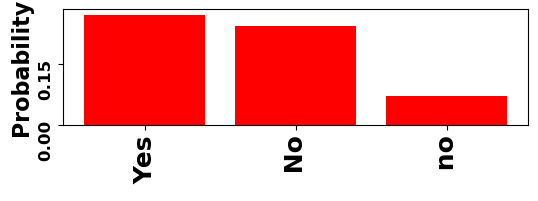

In [42]:
import torch
k = 3
logit_vector = logits[loss_position].detach()             

# Compute softmax probabilities
probs = torch.softmax(logit_vector, dim=-1)

# Get top k probabilities and their indices
top_probs, top_indices = torch.topk(probs, k)
top_tokens = [tokenizer.decode([idx]) for idx in top_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,1.5), dpi=100)
bars = plt.bar(range(k), top_probs.cpu().numpy(), tick_label=top_tokens, color='red')
plt.xticks(rotation=90, fontweight='bold', fontsize=18)
# plt.xlabel('Token',rotation=180, fontweight='bold', fontsize=12)
plt.ylabel('Probability', fontweight='bold', fontsize=16,rotation=90)
plt.yticks(rotation=90, fontweight='bold', fontsize=12)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=2))  # increase number of ticks

# plt.title(f'Top {k} Tokens in Softmax of Logits')
plt.show()

### Visualize attribution graph

In [43]:
### Text-based visualization with colored boxes (like highlighted sentence)
from IPython.display import HTML, display
import matplotlib.colors as mcolors



log_color = 1

cmap = plt.get_cmap('Blues')

optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]

tick_label_text = optimized_tokens.copy()
            

if len(grads.shape) == 2:
    grad_magnitude = grads.norm(dim=-1).squeeze()  # shape [seq_len]
else:
    grad_magnitude = grads
    

# Normalize grad_magnitude for color mapping
log_norm = Log_Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())
norm = Norm(vmin=grad_magnitude.min(), vmax=grad_magnitude.max())




if log_color:
    colors = cmap(log_norm(grad_magnitude.cpu().numpy()))
else:
    colors = cmap(norm(grad_magnitude.cpu().numpy()))

# Build HTML with colored boxes around each word, using bold font
def rgba_to_css(rgba):
    """Convert matplotlib RGBA to CSS rgba string"""
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

def get_text_color(bg_rgba):
    """Return white or black text based on background luminance"""
    luminance = 0.299 * bg_rgba[0] + 0.587 * bg_rgba[1] + 0.114 * bg_rgba[2]
    return "white" if luminance < 0.5 else "black"

html_parts = []
for i, (token, color) in enumerate(zip(tick_label_text, colors)):
    bg_color = rgba_to_css(color)
    text_color = get_text_color(color)
    
    # # Special styling for target token
    # if i == bar_idx and hardset_target_grad:
    #     # bg_color = "black"
    #     bg_color = "red"
    #     text_color = "white"
    
    # Clean up token display (remove leading space for display but keep for meaning)
    display_token = token if token.strip() else "·"  # show dot for whitespace-only tokens
    
    html_parts.append(
        f'<span style="'
        f'background-color: {bg_color}; '
        f'color: {text_color}; '
        f'padding: 0px 9px; '
        f'margin: 2px; '
        f'border-radius: 8px; '
        f'font-family: monospace; '
        f'font-size: 16px; '
        f'display: inline-block; '
        f'font-weight: bold;'   # <-- bold font here
        f'">{display_token}</span>'
    )

# === OPTION A: HTML display with fixed width ===
html_str = f'''
<div style="
    background: white; 
    padding: 20px; 
    border-radius: 8px; 
    line-height: 2.2;
    width: 550px;
    # width: 1100px;
">
    {"".join(html_parts)}
</div>
'''
display(HTML(html_str))


In [44]:
grad_magnitude = grads.norm(dim=-1).squeeze() 
optimized_tokens = [decoded_tokens[idx] for idx in grad_idx]
tick_label_text = optimized_tokens.copy()


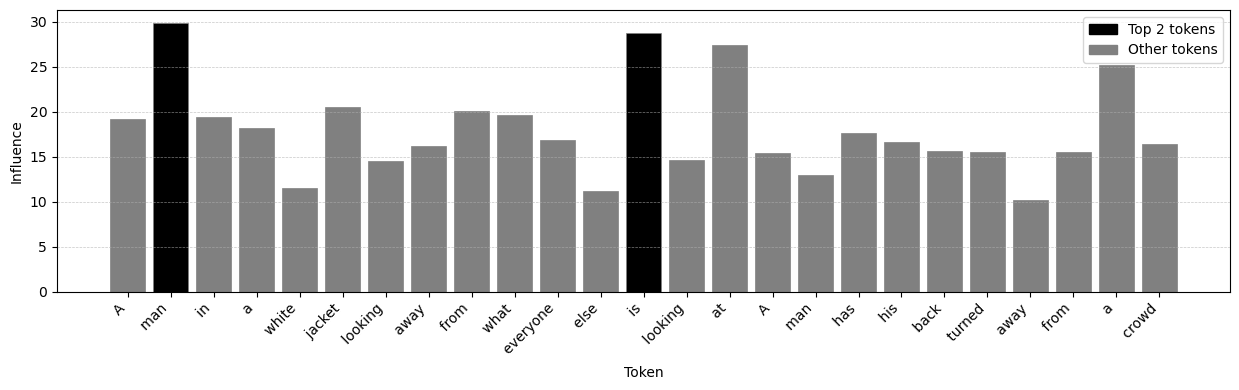

: 

In [ ]:
# Barplot of attribution scores
grad_vals = grad_magnitude.cpu().numpy()
if grad_vals.ndim > 1:
    grad_vals = grad_vals.squeeze()

# Determine the top top_k_fraction indices
n_top = max(1, int(len(grad_vals) * top_k_fraction))
top_indices = grad_vals.argsort()[::-1][:n_top]

# Assign colors: gray for top tokens, blue otherwise
bar_colors = []
for i in range(len(grad_vals)):
    if i in top_indices:
        bar_colors.append('black')
    else:
        bar_colors.append('gray')

fig, ax = plt.subplots(figsize=(max(10, len(tick_label_text) * 0.5), 4))
ax.bar(range(len(tick_label_text)), grad_vals, color=bar_colors, edgecolor='gray', linewidth=0.5)
ax.set_xticks(range(len(tick_label_text)))
ax.set_xticklabels([t if t.strip() else '·' for t in tick_label_text], rotation=45, ha='right')
ax.set_xlabel('Token')
ax.set_ylabel('Influence')
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

legend_patches = [
    plt.matplotlib.patches.Patch(color='black', label=f'Top {n_top} tokens'),
    plt.matplotlib.patches.Patch(color='gray', label='Other tokens')
]
ax.legend(handles=legend_patches, loc='best')

plt.tight_layout()
plt.show()


### Ablation

In [ ]:
# Replace top influential tokens with all-zero embeddings and recompute logits
presence_ablated = presence.clone()
for i in top_indices:
    position = grad_idx[int(i)]
    presence_ablated[position, 0] = 0.0

# Reload the model to ensure a clean state after ablation
del model
torch.cuda.empty_cache()
if device == "cpu":
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)
    model = model.to(device)
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name, device_map="auto")
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
model.eval()

forward_pass_ablated = JCBScope_utils.customize_forward_pass(
    model, residual, presence_ablated, input_ids, grad_idx, attention_mask
)

with torch.no_grad():
    _, logits_ablated = forward_pass_ablated(
        loss_position=loss_position,
        hidden_norm_as_loss=hidden_norm_as_loss,
        unnormalized_logits=unnormalized_logits,
        tie_input_output_embed=False,
    )

# Compute log probabilities for original and ablated logits
log_probs_orig = torch.log_softmax(logits[loss_position], dim=-1)
log_probs_ablated = torch.log_softmax(logits_ablated[loss_position], dim=-1)

# Find the index of the most likely token before ablation
max_idx_orig = log_probs_orig.argmax().item()
max_log_prob_orig = log_probs_orig[max_idx_orig].item()
max_log_prob_ablated = log_probs_ablated[max_idx_orig].item()

delta_log_prob = max_log_prob_ablated - max_log_prob_orig

print(f"Change in log probability of the most likely pre-ablation token (token id {max_idx_orig}, {tokenizer.decode([max_idx_orig])!r}): {delta_log_prob:.4f}")

Loading checkpoint shards:  25%|██▌       | 1/4 [00:32<01:38, 32.92s/it]